In [9]:
import radiate as rd
import polars as pl
from IPython.display import display, HTML

rd.random.seed(33)

In [10]:
def compute(x: float) -> float:
    return 4.0 * x**3 - 3.0 * x**2 + x


inputs = []
answers = []

input = -1.0
for _ in range(-10, 10):
    input += 0.1
    inputs.append([input])
    answers.append([compute(input)])

In [11]:
collector = rd.MetricCollector()

slope = rd.Expr.select("scores.best").slope()

engine = (
    rd.Engine.graph(
        shape=(1, 1),
        vertex=[rd.Op.sub(), rd.Op.mul(), rd.Op.linear()],
        edge=rd.Op.weight(),
        output=rd.Op.linear(),
    )
    .regression(inputs, answers, loss=rd.MSE)
    .subscribe(collector)
    .metrics(slope=slope)
    .alters(
        rd.Cross.graph(0.05, 0.5),
        rd.Mutate.op(0.07, 0.05),
        rd.Mutate.graph(0.1, 0.1, False),
    )
    .limit(rd.Limit.score(0.001), rd.Limit.generations(1000))
)

result = engine.run(log=True)

2026-07-04T05:09:13.999028Z  INFO Epoch 1    | Score:   2.0038 | Time: 318.75µs
2026-07-04T05:09:13.999213Z  INFO Epoch 2    | Score:   2.0038 | Time: 459.62µs
2026-07-04T05:09:13.999286Z  INFO Epoch 3    | Score:   2.0038 | Time: 516.12µs
2026-07-04T05:09:13.999359Z  INFO Epoch 4    | Score:   1.6821 | Time: 578.67µs
2026-07-04T05:09:13.999430Z  INFO Epoch 5    | Score:   1.6821 | Time: 641.21µs
2026-07-04T05:09:13.999502Z  INFO Epoch 6    | Score:   1.6821 | Time: 704.00µs
2026-07-04T05:09:13.999559Z  INFO Epoch 7    | Score:   1.6821 | Time: 751.96µs
2026-07-04T05:09:13.999630Z  INFO Epoch 8    | Score:   1.6821 | Time: 816.96µs
2026-07-04T05:09:13.999702Z  INFO Epoch 9    | Score:   1.6821 | Time: 880.75µs
2026-07-04T05:09:13.999764Z  INFO Epoch 10   | Score:   1.6821 | Time: 937.08µs
2026-07-04T05:09:13.999820Z  INFO Epoch 11   | Score:   1.6821 | Time: 986.17µs
2026-07-04T05:09:13.999876Z  INFO Epoch 12   | Score:   1.6821 | Time: 1.03ms
2026-07-04T05:09:13.999929Z  INFO Epoch 13

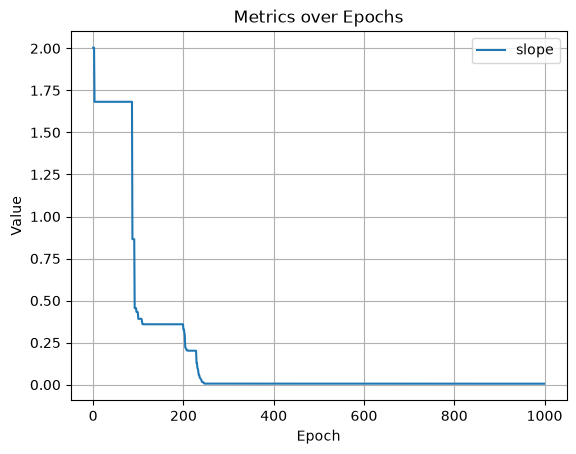

In [12]:
collector.plot("slope")
# print(result.metrics().dashboard())

In [13]:
eval_results = result.value().eval(inputs)
accuracy = rd.accuracy(result.value(), inputs, answers, loss=rd.MSE)
accuracy

PyAccuracy("Regression Accuracy" {
	N: 20 
	Accuracy: 99.20%
	R² Score: 0.99852
	RMSE: 0.07766
	Loss (MSE): 0.00603
})

In [14]:
df = collector.to_polars(lazy=False)
df

name,last,sum,mean,stddev,var,skew,min,max,count,time_sum,time_mean,time_stddev,time_min,time_max,time_var,generation,update_count,tags
str,f64,f64,f64,f64,f64,f64,f64,f64,i64,duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],duration[μs],i64,i64,list[str]
"""count.evaluation""",6.0,106.0,53.0,66.46804,4418.0,NaN,6.0,100.0,2,null,null,null,null,null,null,0,2,"[""statistic""]"
"""step.evaluate.time""",0.000036,0.000113,0.000056,0.000029,8.6287e-10,NaN,0.000036,0.000077,2,112µs,56µs,29µs,35µs,77µs,0µs,0,2,"[""time"", ""step""]"
"""selector.roulette""",20.0,20.0,20.0,0.0,0.0,NaN,20.0,20.0,1,null,null,null,null,null,null,0,1,"[""selector"", ""statistic""]"
"""selector.roulette.time""",0.000007,0.000007,0.000007,0.0,0.0,NaN,0.000007,0.000007,1,6µs,6µs,0µs,6µs,6µs,0µs,0,1,"[""selector"", ""time""]"
"""selector.tournament""",80.0,80.0,80.0,0.0,0.0,NaN,80.0,80.0,1,null,null,null,null,null,null,0,1,"[""selector"", ""statistic""]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""slope""",0.006031,203.217712,0.203218,0.478174,0.22865,0.0,0.006031,2.003778,1000,null,null,null,null,null,null,999,1,"[""statistic"", ""expr""]"
"""step.metric.time""",0.000011,0.011265,0.000011,0.000002,5.7478e-12,0.0,0.000009,0.000061,1000,11265µs,11µs,2µs,9µs,61µs,0µs,999,1,"[""time"", ""step""]"
"""time""",0.00026,0.206634,0.000207,0.000071,5.0686e-9,0.0,0.00004,0.000503,1000,206634µs,206µs,71µs,39µs,503µs,0µs,999,1,"[""time""]"


In [15]:
filtered = (
    df.filter(pl.col("name") == "score.improvement")
    .select("generation")
    .unique()
    .sort("generation")
)
filtered

generation
i64
0
1
2
3
4
…
995
996
997


In [16]:
display(HTML(filtered._repr_html_()))

generation
i64
0
1
2
3
4
…
995
996
997
